In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt

def init_naive(in_dim, out_dim):
    return torch.randn(in_dim, out_dim) * 0.01

def init_xavier(in_dim, out_dim):
    std = np.sqrt(2.0 / (in_dim + out_dim))
    return torch.randn(in_dim, out_dim) * std

def init_kaiming(in_dim, out_dim):
    std = np.sqrt(2.0 / in_dim)
    return torch.randn(in_dim, out_dim) * std

In [2]:

def analyze_initialization(init_fn, num_layers=20, layer_dim=100, batch_size=256):
    X = torch.randn(batch_size, layer_dim)

    weights = []
    for _ in range(num_layers):
        W = init_fn(layer_dim, layer_dim)
        W.requires_grad = False
        weights.append(W)

    layer_means = []
    layer_vars = []

    A = X
    for i, W in enumerate(weights):
        Z = A @ W
        A = torch.relu(Z)

        layer_means.append(A.mean().item())
        layer_vars.append(A.var().item())

    return layer_means, layer_vars

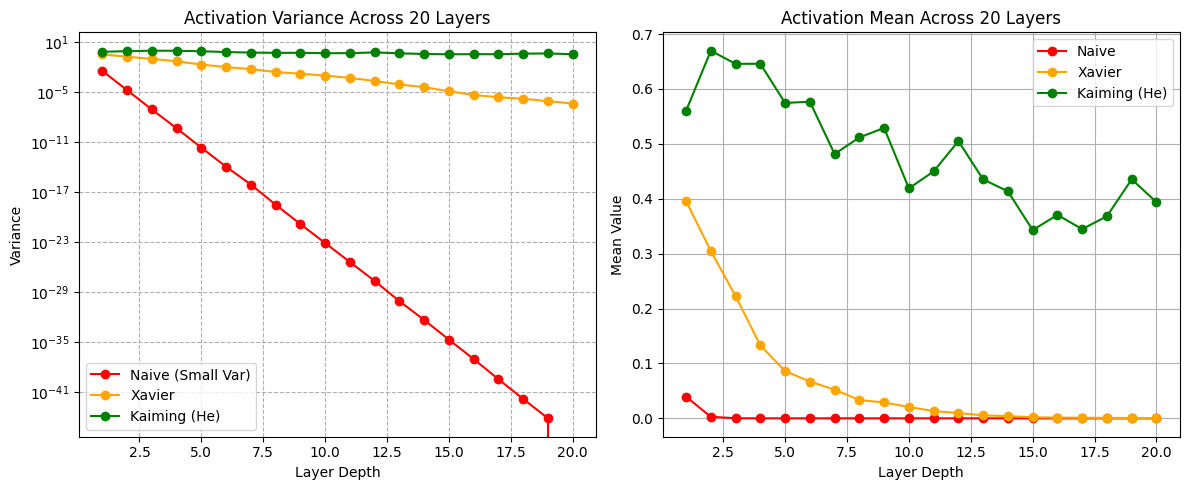

In [3]:
means_naive, vars_naive = analyze_initialization(init_naive)
means_xavier, vars_xavier = analyze_initialization(init_xavier)
means_kaiming, vars_kaiming = analyze_initialization(init_kaiming)

layers = list(range(1, 21))
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(layers, vars_naive, label="Naive (Small Var)", marker='o', color='red')
plt.plot(layers, vars_xavier, label="Xavier", marker='o', color='orange')
plt.plot(layers, vars_kaiming, label="Kaiming (He)", marker='o', color='green')
plt.title("Activation Variance Across 20 Layers")
plt.xlabel("Layer Depth")
plt.ylabel("Variance")
plt.yscale("log")
plt.grid(True, which="both", ls="--")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(layers, means_naive, label="Naive", marker='o', color='red')
plt.plot(layers, means_xavier, label="Xavier", marker='o', color='orange')
plt.plot(layers, means_kaiming, label="Kaiming (He)", marker='o', color='green')
plt.title("Activation Mean Across 20 Layers")
plt.xlabel("Layer Depth")
plt.ylabel("Mean Value")
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()